# EDA Final: Diagnóstico de Errores de Pronóstico Climático

Este notebook consolida el análisis estadístico de los errores de pronóstico frente a observaciones reales, con el fin de fundamentar la estrategia de Machine Learning.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_theme(style="whitegrid")
df = pd.read_parquet("local_cleanup/clima_unificado.parquet")


# 1. Limpieza de viento (Conversión de mph a float)
def clean_wind(val):
    if isinstance(val, str) and "mph" in val:
        return float(val.replace(" mph", ""))
    try:
        return float(val)
    except:
        return np.nan


df["wind_speed_fcst"] = df["wind_speed_fcst"].apply(clean_wind)
df["hour"] = df["obs_timestamp"].dt.hour

# 2. Cálculo de errores (Residuos)
df["err_temp"] = df["temp_fcst"] - df["temp_real"]
df["err_hum"] = df["hum_fcst"] - df["hum_real"]
df["err_wind"] = df["wind_speed_fcst"] - df["wind_speed_real"]
df["err_dew"] = df["dew_fcst"] - df["dew_real"]


print(f"Dataset cargado y limpio: {len(df)} registros.")

Dataset cargado y limpio: 91822 registros.


## 1. Correlacion entre variables

**Observaciónes:**

- Correlacion fuerte entre `temp_real`, `dew_real` y `hum_real`, esperable por la relacion fisica entre las variables.


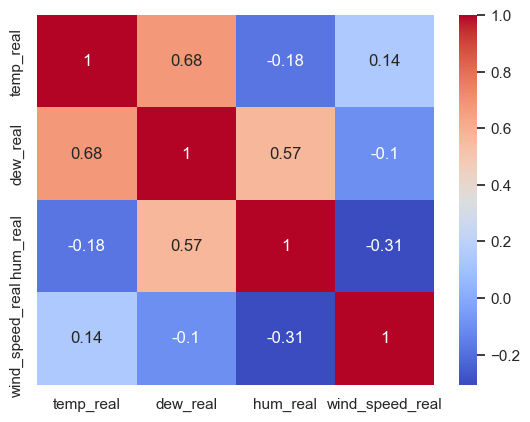

In [9]:
vars = ["temp_real", "dew_real", "hum_real", "wind_speed_real"]
sns.heatmap(df[vars].corr(), annot=True, cmap="coolwarm")
plt.show()

## 3. Análisis de Sesgo Diurno

**Observaciones:**

- Se detecta una **sobreestimación nocturna** constante y una **subestimación diurna**.
- Esto sugiere que el modelo de ML necesita la hora como variable predictora, preferiblemente transformada en componentes sinusoidales.


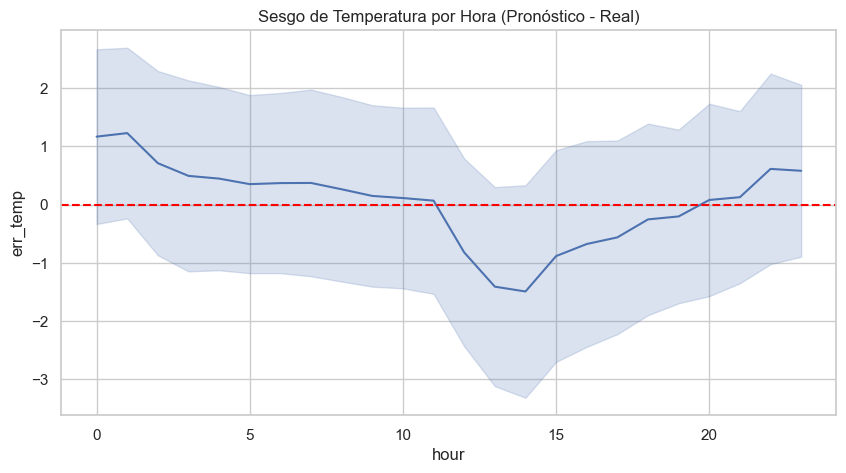

In [2]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x="hour", y="err_temp", errorbar="sd")
plt.axhline(0, color="red", linestyle="--")
plt.title("Sesgo de Temperatura por Hora (Pronóstico - Real)")
plt.show()

## 4. Persistencia Temporal (Lags)

**Observaciones:**

- El error actual está altamente correlacionado con el error de la hora anterior (~0.66).
- **Estrategia:** Incluir lags de 1h y 3h como características del modelo.


In [3]:
df = df.sort_values(["station_id", "obs_timestamp"])
df["err_temp_lag1"] = df.groupby("station_id")["err_temp"].shift(1)
corr_lag = df[["err_temp", "err_temp_lag1"]].corr().iloc[0, 1]
print(f"Correlación Lag 1h: {corr_lag:.3f}")

Correlación Lag 1h: 0.664


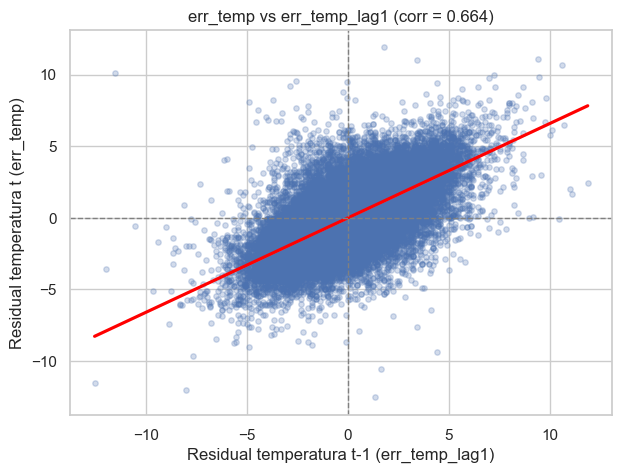

In [6]:
# Relación entre residual actual y residual con lag de 1h
plot_df = df[["err_temp", "err_temp_lag1"]].dropna()

plt.figure(figsize=(7, 5))
sns.regplot(
    data=plot_df,
    x="err_temp_lag1",
    y="err_temp",
    scatter_kws={"alpha": 0.25, "s": 15},
    line_kws={"color": "red"},
)
plt.title(f"err_temp vs err_temp_lag1 (corr = {corr_lag:.3f})")
plt.xlabel("Residual temperatura t-1 (err_temp_lag1)")
plt.ylabel("Residual temperatura t (err_temp)")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.show()

## 5. Distribución de Residuos

**Observaciones:**

- El **error de viento** muestra un sesgo negativo sistemático importante (~ -5 mph).
- Tras filtrar el glitch de la NWS (60°C), la temperatura muestra una distribución mucho más centrada y simétrica.



Estadísticas para err_temp:
Mean Bias: 0.0004
MAE: 1.3378
Kurtosis: 1.3416

Estadísticas para err_hum:
Mean Bias: -1.2426
MAE: 6.6916
Kurtosis: 1.6361

Estadísticas para err_wind:
Mean Bias: -5.0481
MAE: 6.2454
Kurtosis: 0.4851

Estadísticas para err_dew:
Mean Bias: -0.1353
MAE: 1.2405
Kurtosis: 4.0161


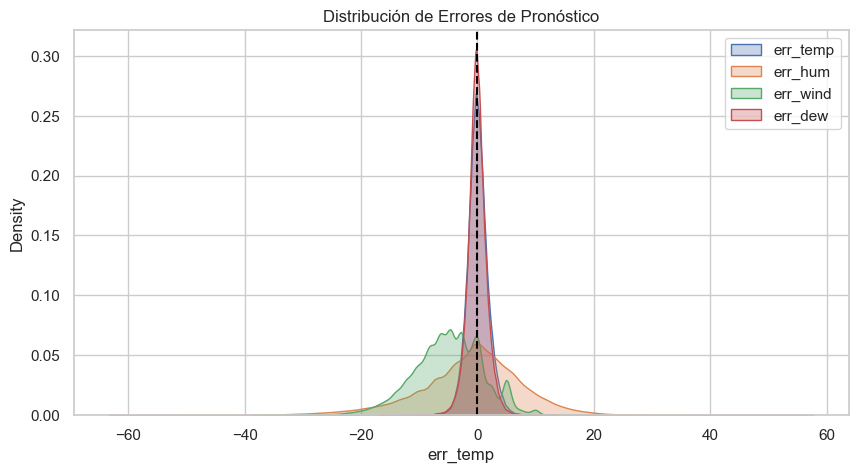

In [8]:
err_vars = ["err_temp", "err_hum", "err_wind", "err_dew"]
for var in err_vars:
    print(f"\nEstadísticas para {var}:")
    print(f"Mean Bias: {df[var].mean():.4f}")
    print(f"MAE: {df[var].abs().mean():.4f}")
    print(f"Kurtosis: {kurtosis(df[var].dropna()):.4f}")

plt.figure(figsize=(10, 5))
for var in err_vars:
    sns.kdeplot(df[var], label=var, fill=True, alpha=0.3)
plt.axvline(0, color="black", linestyle="--")
plt.legend()
plt.title("Distribución de Errores de Pronóstico")
plt.show()

## 7. Variabilidad Espacial

**Observaciones:**

- El error es consistente en la zona central, con microclimas cerca de lagos.


MAE global de temperatura: 1.338 °C


,station_id,mae_temp,n_obs
424,KRNP,2.838570,174
94,KCDR,2.143126,177
353,KMWT,2.075810,175
240,KHOB,2.068571,175
383,KP28,2.047316,178
130,KDHT,2.039178,173
344,KMRF,2.037244,179
202,KGAG,2.003788,176
474,KTCC,1.982423,177
87,KCAO,1.952732,181


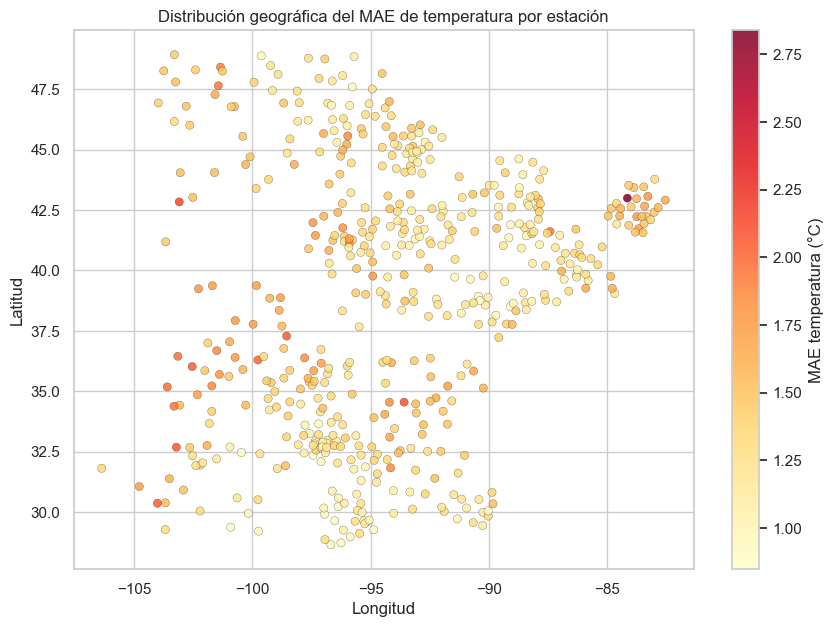

In [11]:
# MAE de temperatura por estación (agrupado espacialmente)
temp_mae_geo = (
    df.dropna(subset=["err_temp", "lat_estacion", "lon_estacion"])
    .groupby("station_id", as_index=False)
    .agg(
        lat_estacion=("lat_estacion", "first"),
        lon_estacion=("lon_estacion", "first"),
        mae_temp=("err_temp", lambda x: np.mean(np.abs(x))),
        n_obs=("err_temp", "count"),
    )
)

print(f"MAE global de temperatura: {df['err_temp'].abs().mean():.3f} °C")
display(
    temp_mae_geo[["station_id", "mae_temp", "n_obs"]]
    .sort_values("mae_temp", ascending=False)
    .head(10)
)

# Distribución geográfica del MAE en el área de estudio
plt.figure(figsize=(10, 7))
sc = plt.scatter(
    temp_mae_geo["lon_estacion"],
    temp_mae_geo["lat_estacion"],
    c=temp_mae_geo["mae_temp"],
    cmap="YlOrRd",
    s=35,
    alpha=0.85,
    edgecolor="k",
    linewidth=0.2,
)

plt.colorbar(sc, label="MAE temperatura (°C)")
plt.title("Distribución geográfica del MAE de temperatura por estación")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
# plt.xlim(-106, -86)  # centro de EE.UU. (aprox.)
# plt.ylim(30, 49)
plt.show()

## 8. Análisis de Sesgo Condicional

**Observaciones:**

- Mayor dispersión en extremos térmicos (<5C o >35C).


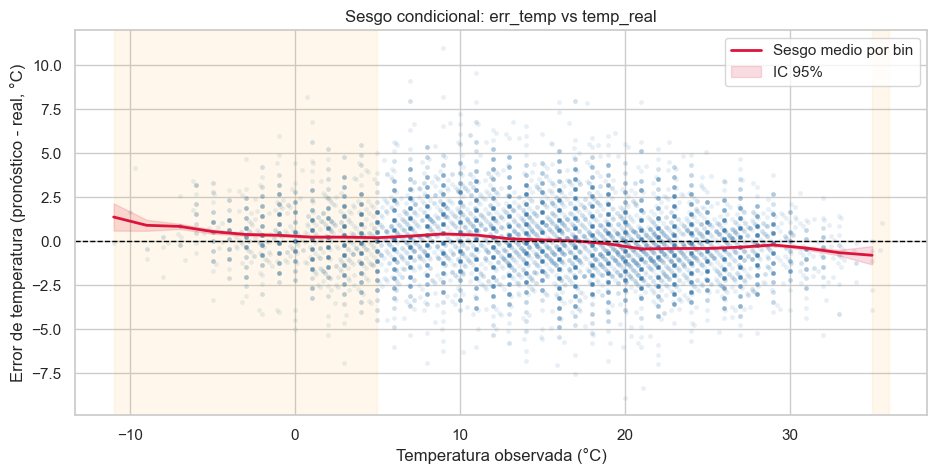

In [12]:
# Sesgo condicional de temperatura: error en función de la temperatura observada
cond_df = df[["temp_real", "err_temp"]].dropna().copy()

# Bins de 2°C para estabilizar la señal
bins = np.arange(
    np.floor(cond_df["temp_real"].min() / 2) * 2,
    np.ceil(cond_df["temp_real"].max() / 2) * 2 + 2,
    2,
)
cond_df["temp_bin"] = pd.cut(cond_df["temp_real"], bins=bins, include_lowest=True)

bias_by_bin = (
    cond_df.groupby("temp_bin", observed=False)["err_temp"]
    .agg(mean_bias="mean", std="std", n="count")
    .reset_index()
)
bias_by_bin["temp_center"] = bias_by_bin["temp_bin"].apply(lambda x: x.mid)
bias_by_bin["ci95"] = 1.96 * (bias_by_bin["std"] / np.sqrt(bias_by_bin["n"]))

plt.figure(figsize=(11, 5))

# Nube de puntos suave para contexto
sns.scatterplot(
    data=cond_df.sample(min(12000, len(cond_df)), random_state=42),
    x="temp_real",
    y="err_temp",
    alpha=0.12,
    s=12,
    color="steelblue",
)

# Sesgo promedio por rango térmico + IC
plt.plot(
    bias_by_bin["temp_center"],
    bias_by_bin["mean_bias"],
    color="crimson",
    lw=2,
    label="Sesgo medio por bin",
)
plt.fill_between(
    bias_by_bin["temp_center"],
    bias_by_bin["mean_bias"] - bias_by_bin["ci95"],
    bias_by_bin["mean_bias"] + bias_by_bin["ci95"],
    color="crimson",
    alpha=0.15,
    label="IC 95%",
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvspan(cond_df["temp_real"].min(), 5, color="orange", alpha=0.08)
plt.axvspan(35, cond_df["temp_real"].max(), color="orange", alpha=0.08)

plt.title("Sesgo condicional: err_temp vs temp_real")
plt.xlabel("Temperatura observada (°C)")
plt.ylabel("Error de temperatura (pronóstico - real, °C)")
plt.legend()
plt.show()

## 9. Conclusiones y Estrategia de Modelado

### Hallazgos Críticos

1. **Glitch de Proveedor:** Se confirmó que valores > 50°C eran errores técnicos de la NWS (Milwaukee), los cuales ya fueron filtrados en el pipeline de unificación.
2. **Error de Viento:** Es el principal objetivo de corrección por su sesgo sistemático constante.
3. **Acoplamiento Temp-Hum-Dew:** Existe una fuerte dependencia física entre los errores de estas variables.

### Próximos Pasos (Feature Engineering)

- Generar variables cíclicas para `hour`.
- Crear ventanas de `lags` (t-1, t-3).
- Implementar modelos de ensamble (XGBoost/LightGBM) para predecir los residuos identificados.
